In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

$$
\nabla^2 u(x) +\frac{\omega_0^2}{c(x)^2}u(x) = -f(x)
$$
where $\omega_0 = \frac{2\pi}{\lambda}$ is the `angular frequency`, $c(x)$ is the `sound of speed(SOS)` and $f(x)$ is the point source term.

we can set $k =\frac{\omega_0}{c(x)}$, then 
$$
\nabla^2 u(x) +k^2u(x) = -f(x)
$$

In Convergent Born Series, the scatter potential is defined as:
$$
V = k^2 - k^2_0 - i\epsilon
$$

In [3]:
def plot2Dimage(x_start=0,x_end=128,
                y_start=0,y_end=128,
                dx=1,f=None,
                cmap='RdBu_r',
                title="Wave Field",
                x_label='X',
                y_label='Y',
                figsize=(7,5),
                levels=100):
    x = torch.arange(x_start,x_end)*dx
    y = torch.arange(y_start,y_end)*dx
    X ,Y = torch.meshgrid(x,y,indexing='ij')
    X = X.flatten()
    Y = Y.flatten()
    u = f.flatten()
    fig, ax = plt.subplots(figsize=figsize)
    image = ax.tricontourf(X,Y,u,levels=levels,cmap=cmap)
    cbar = plt.colorbar(image)
    cbar.ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3e'))
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.invert_yaxis()
    plt.show()

In [4]:
class ConvergentBornSeries(nn.Module):
    def __init__(self,
                 lamb=1,
                 sos=None,
                 dx=None,
                 src_loc=[30,60],
                 boundary_width=[8,8],
                 boundary_strength=1,
                 boundary_type='PML5'
                 ):
        super().__init__()
        # PDE params
        self.lamb = lamb # wavelength, the units depend on the length units of the spacial field
        self.omega0 = 2*torch.pi/self.lamb
        self.PPW = 4 # points per wavelength
        if dx is None:# default dx = 1/4 wavelength
            self.pixel_size = self.lamb / self.PPW 
        else:
            self.pixel_size = dx
        if sos is None:
            # It is not difficult to understand from the Helmholtz equation that: 
            # the wavelength is determined by the velocity field (sos) and the coefficient lambda(lamb).
            # But our defalut pixel_size is only adjusted according to the value of lambda
            # Therefore, when we adjust lambda, the appearance of the resulting wavefield remains unchanged. 
            # This is because the pixel_size becomes larger.Actually, the physical space got bigger.
            # But when we adjust the velocity field, the appearance of resulting wave field will change, 
            # because the velocity field does not affect our grid spacing
            num_waves = 32# number of waves
            self.N = num_waves*torch.tensor([self.PPW, self.PPW],dtype=int)
            self.sos = torch.ones(self.N[0],self.N[1])+\
                       torch.sin(torch.linspace(0,8,self.N[0]).view(-1,1))*torch.ones(1,self.N[1])*0.5
        else:
            self.sos = sos
            self.N = torch.tensor(sos.size()).to(int)

        self.inv_sos2 = 1/self.sos**2
        inv_sos2_center = (torch.max(self.inv_sos2) + torch.min(self.inv_sos2))/2
        
        src_loc = torch.tensor(src_loc,dtype=int).view(2,-1) # single point source
        self.src = torch.sparse_coo_tensor(indices=src_loc,values=1.,size=(self.sos.size(0),self.sos.size(1)))

        # boundary
        self.boundary_widths = torch.tensor(boundary_width,dtype=int)
        self.boundary_strength = boundary_strength
        self.boundary_type = boundary_type
        self.set_grid()
        self.set_boundary()

        # CBS params
        self.k0 = torch.sqrt(inv_sos2_center)*self.omega0
        self.epsilon = torch.max(torch.abs(self.inv_sos2*self.omega0**2 - self.k0**2))
        # scatter potential
        self.V = self.inv_sos2*self.omega0**2 - self.k0**2 - 1.0j*self.epsilon
        # g0_tilde
        self.g0 = (1/(self.px_range**2+self.py_range**2-self.k0**2 - 1.0j*self.epsilon))
        # plot2Dimage(x_end=self.g0.size(0),
        #             y_end=self.g0.size(1),
        #             f=torch.fft.fftshift(torch.real(self.g0)),title=r'real part of $\tilde{g}_0$')
    def solve(self,max_iters=2000,tol=1e-16):
        self.u = torch.zeros(self.new_N[0],self.new_N[1])
        for i in range(max_iters):
            
            # self.src_loc_ = self.
            tmp1 = self.V*self.u
            # tmp1 -=torch.real(tmp1)
            # point source
            tmp1[self.roi[0][0]:self.roi[0][1],self.roi[1][0]:self.roi[1][1]] += self.src

            tmp2 = (1.j/self.epsilon*self.V) * (self.u - torch.fft.ifftn(self.g0 * torch.fft.fftn(tmp1)))
            self.u = self.u - tmp2
    def set_grid(self):
        # set grid in spacial and spectral domains

        self.new_N = (2**(torch.ceil(torch.log2(self.N + self.boundary_widths)))).to(int) # To improve FFT efficiency

        self.padding_size = self.new_N - self.N - self.boundary_widths # zero padding, placed at right and bottom sides only (non-centric)
        # spacial coordinates
        # debug: why N[1] is x
        self.x_range = (torch.arange(self.new_N[0])*self.pixel_size).view(-1,1)
        self.y_range = (torch.arange(self.new_N[1])*self.pixel_size)
        # spectral coordinates
        self.px_range = 2*torch.pi*torch.fft.fftfreq(self.new_N[0],d=self.pixel_size).view(-1,1)
        self.py_range = 2*torch.pi*torch.fft.fftfreq(self.new_N[1],d=self.pixel_size)

    def set_boundary(self): 
        # add padding
        self.roi_size = torch.tensor(self.sos.size())
        self.Bl = torch.ceil((self.new_N - self.roi_size)/2).to(int)
        self.Br = torch.floor((self.new_N - self.roi_size)/2).to(int)
        self.roi = [[self.Bl[0],self.Bl[0]+self.roi_size[0]],
                    [self.Bl[1],self.Bl[1]+self.roi_size[1]]]

        self.inv_sos2 = F.pad(self.inv_sos2.unsqueeze(0), 
                              (self.Bl[1], self.Br[1], self.Bl[0], self.Br[0]), 
                              mode='replicate').squeeze()
        # add boundary
        Bmax = torch.max(self.Br)
        # debug: why divide self.pixel_size ?
        k0 = torch.sqrt(torch.mean(self.inv_sos2))*2*torch.pi/(self.lamb/self.pixel_size)# k0 in 1/pixels
        # maximum value of the boundary (see Mathematica file = c(c-2ik0) = boundary_strength)
        # ||^2 = |c|^2 (|c|^2 + 4k0^2)   [assuming c=real, better possible when c complex?]
        # when |c| << |2k0| we can approximage: boundary_strength = 2 k0 c
        c = self.boundary_strength*k0**2 / (2*k0)
        x = torch.cat((torch.arange(self.Bl[0], 0, -1), torch.zeros(self.roi_size[0]), torch.arange(1, self.Br[0] + 1))).view(-1,1)
        y = torch.cat((torch.arange(self.Bl[1], 0, -1), torch.zeros(self.roi_size[1]), torch.arange(1, self.Br[1] + 1)))
        dist = torch.sqrt(x**2 + y**2)
        # the shape of the boundary is determined by f_boundary_curve, a function
        # that takes a position (in pixels, 0=start of boundary) and returns
        # Delta inv_sos2 for the boundary. 
        f_boundary_curve, leakage = self.compute_leakage_and_boundary_curve(boundary_type=self.boundary_type,
                                                                            r=dist,
                                                                            Bmax=Bmax,
                                                                            c=c,
                                                                            k0=k0)

        self.inv_sos2 = self.inv_sos2 + f_boundary_curve
        
        self.leakage = leakage

    def compute_leakage_and_boundary_curve(self,boundary_type, r, Bmax, c, k0):
        # cannot understand this
        if boundary_type == 'PML5':  # 5th order smooth
            f_boundary_curve = 1 / k0**2 * (c**7 * r**5 * (6.0 + (2.0j * k0 - c) * r)) / \
                (720 + 720 * c * r + 360 * c**2 * r**2 + 120 * c**3 * r**3 + 30 * c**4 * r**4 + 6 * c**5 * r**5 + c**6 * r**6)
            leakage = torch.exp(-c * Bmax) * (720 + 720 * c * Bmax + 360 * c**2 * Bmax**2 + 
                                            120 * c**3 * Bmax**3 + 30 * c**4 * Bmax**4 + 
                                            6 * c**5 * Bmax**5 + c**6 * Bmax**6) / 24
        elif boundary_type == 'PML4':  # 4th order smooth
            f_boundary_curve = 1 / k0**2 * (c**6 * r**4 * (5.0 + (2.0j * k0 - c) * r)) / \
                (120 + 120 * c * r + 60 * c**2 * r**2 + 20 * c**3 * r**3 + 5 * c**4 * r**4 + c**5 * r**5)
            leakage = torch.exp(-c * Bmax) * (120 + 120 * c * Bmax + 60 * c**2 * Bmax**2 + 
                                            20 * c**3 * Bmax**3 + 5 * c**4 * Bmax**4 + c**5 * Bmax**5) / 24
        elif boundary_type == 'PML3':  # 3rd order smooth
            f_boundary_curve = 1 / k0**2 * (c**5 * r**3 * (4.0 + (2.0j * k0 - c) * r)) / \
                (24 + 24 * c * r + 12 * c**2 * r**2 + 4 * c**3 * r**3 + c**4 * r**4)
            leakage = torch.exp(-c * Bmax) * (24 + 24 * c * Bmax + 12 * c**2 * Bmax**2 + 
                                            4 * c**3 * Bmax**3 + c**4 * Bmax**4) / 24
        elif boundary_type == 'PML2':  # 2nd order smooth
            f_boundary_curve = 1 / k0**2 * (c**4 * r**2 * (3.0 + (2.0j * k0 - c) * r)) / \
                (6 + 6 * c * r + 3 * c**2 * r**2 + c**3 * r**3)
            leakage = torch.exp(-c * Bmax) * (6 + 6 * c * Bmax + 3 * c**2 * Bmax**2 + c**3 * Bmax**3) / 6
        elif boundary_type == 'PML1':  # 1st order smooth
            f_boundary_curve = 1 / k0**2 * (c**3 * r * (2.0 + (2.0j * k0 - c) * r)) / \
                (2.0 + 2.0 * c * r + c**2 * r**2) / k0**2 # (divide by k0^2 to get relative e_r)
            leakage = torch.exp(-c * Bmax) * (2 + 2 * c * Bmax + c**2 * Bmax**2) / 2
        else:
            raise ValueError(f"Unknown boundary type: {boundary_type}")
        return f_boundary_curve, leakage
    def get_u(self):
        return self.u[self.roi[0][0]:self.roi[0][1],self.roi[1][0]:self.roi[1][1]].detach().cpu()

In [5]:
model = ConvergentBornSeries(lamb=1,
                             sos=None,# default homogenous
                             dx=None,
                             src_loc=[40,60],
                             boundary_width=[20,20],
                             boundary_strength=1,
                             boundary_type='PML3')

In [6]:
model.solve(max_iters=1000)
u = model.get_u()

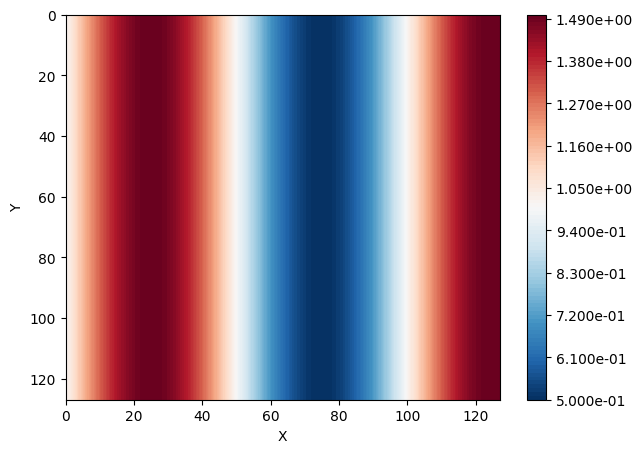

In [7]:
sos = model.sos
plot2Dimage(x_end=sos.size(0),
            y_end=sos.size(1),
            f=sos,
            title='',
            cmap='RdBu_r')

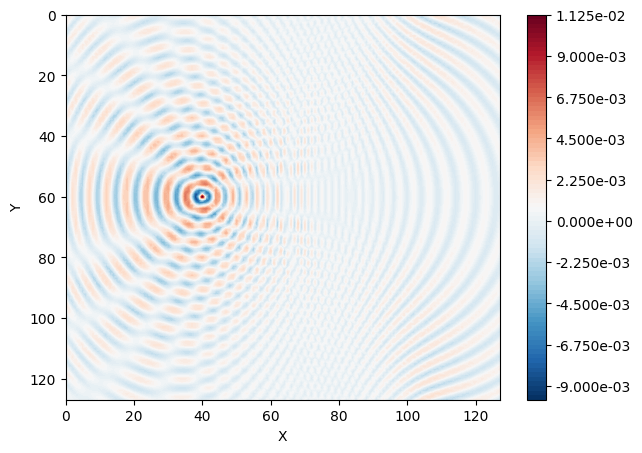

In [7]:
u = torch.real(model.get_u())
plot2Dimage(x_end=u.size(0),
            y_end=u.size(1),
            f=u,
            title='',
            cmap='RdBu_r')